# Agregación de datos por categoría

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
n = 1000
gender = ["Male", "Female"]
social_class = ["Poor", "Middle Class", "Rich"]

gender_data = []
social_class_data = []
for i in range(n):
    gender_data.append(np.random.choice(gender))
    social_class_data.append(np.random.choice(social_class))

income = 18000 + 2500 * np.random.randn(n)
weight = 70 + 15 * np.random.randn(n)
height = 167 +15 * np.random.randn(n)

In [4]:
type(income)
type(weight)
type(height)

numpy.ndarray

In [5]:
people_sample = pd.DataFrame({
    "Gender": gender_data,
    "Social Class": social_class_data,
    "Income": income,
    "Weight": weight,
    "Height": height
    })

In [6]:
people_sample.head(20)

,Gender,Social Class,Income,Weight,Height
0,Male,Rich,19054.268335,64.249207,183.868397
1,Female,Rich,19344.700164,87.258622,171.548272
2,Male,Middle Class,18180.016312,57.718215,180.100129
3,Male,Poor,21427.311330,81.230200,190.610342
4,Female,Poor,16637.346240,78.925128,159.975153
5,Male,Middle Class,15136.785322,53.442477,167.361271
6,Female,Middle Class,19146.155369,65.767689,142.553510
7,Male,Middle Class,16831.769211,59.507667,167.928605
8,Male,Poor,14826.468873,57.387930,156.643017
9,Male,Poor,14900.581029,67.686854,156.195328


## Agrupación de Datos:

Uso del método `.groupby()`

In [7]:
grouped_gender = people_sample.groupby("Gender")

In [8]:
grouped_gender.groups

{'Female': [1, 4, 6, 12, 14, 15, 16, 18, 19, 25, 26, 27, 29, 30, 35, 38, 39, 40, 44, 45, 49, 54, 59, 60, 62, 65, 66, 67, 69, 70, 71, 72, 74, 75, 76, 79, 80, 81, 85, 87, 89, 90, 91, 92, 93, 96, 97, 101, 103, 104, 105, 106, 110, 111, 114, 118, 120, 121, 122, 123, 125, 128, 129, 131, 136, 137, 138, 142, 143, 144, 146, 152, 153, 154, 157, 158, 159, 162, 163, 165, 166, 168, 169, 171, 172, 174, 176, 177, 181, 182, 188, 189, 192, 196, 197, 198, 202, 210, 213, 217, ...], 'Male': [0, 2, 3, 5, 7, 8, 9, 10, 11, 13, 17, 20, 21, 22, 23, 24, 28, 31, 32, 33, 34, 36, 37, 41, 42, 43, 46, 47, 48, 50, 51, 52, 53, 55, 56, 57, 58, 61, 63, 64, 68, 73, 77, 78, 82, 83, 84, 86, 88, 94, 95, 98, 99, 100, 102, 107, 108, 109, 112, 113, 115, 116, 117, 119, 124, 126, 127, 130, 132, 133, 134, 135, 139, 140, 141, 145, 147, 148, 149, 150, 151, 155, 156, 160, 161, 164, 167, 170, 173, 175, 178, 179, 180, 183, 184, 185, 186, 187, 190, 191, ...]}

In [9]:
for names, groups in grouped_gender:
    print(names)
    print(groups)
    print()

Female
     Gender  Social Class        Income     Weight      Height
1    Female          Rich  19344.700164  87.258622  171.548272
4    Female          Poor  16637.346240  78.925128  159.975153
6    Female  Middle Class  19146.155369  65.767689  142.553510
12   Female          Poor  20988.284685  81.175779  157.897422
14   Female          Poor  17139.261330  60.851882  173.984535
..      ...           ...           ...        ...         ...
992  Female  Middle Class  18934.922698  53.168584  138.181020
995  Female          Poor  16684.877794  56.676627  160.134854
996  Female          Poor  18108.708490  69.841899  181.157563
997  Female          Poor  14300.476192  80.884351  159.855946
999  Female          Poor  13348.540961  82.140910  163.182006

[478 rows x 5 columns]

Male
    Gender  Social Class        Income     Weight      Height
0     Male          Rich  19054.268335  64.249207  183.868397
2     Male  Middle Class  18180.016312  57.718215  180.100129
3     Male          P

In [10]:
# Si queremos conocer sólo un grupo en específico, usamos '.get_group("name")'
grouped_gender.get_group("Female")

,Gender,Social Class,Income,Weight,Height
1,Female,Rich,19344.700164,87.258622,171.548272
4,Female,Poor,16637.346240,78.925128,159.975153
6,Female,Middle Class,19146.155369,65.767689,142.553510
12,Female,Poor,20988.284685,81.175779,157.897422
14,Female,Poor,17139.261330,60.851882,173.984535
...,...,...,...,...,...
992,Female,Middle Class,18934.922698,53.168584,138.181020
995,Female,Poor,16684.877794,56.676627,160.134854
996,Female,Poor,18108.708490,69.841899,181.157563
997,Female,Poor,14300.476192,80.884351,159.855946


In [11]:
# Hagamos un doble grupo:
double_group = people_sample.groupby(["Gender", "Social Class"])

In [12]:
for names, groups in double_group:
    print(names)
    print(groups)

('Female', 'Middle Class')
     Gender  Social Class        Income     Weight      Height
6    Female  Middle Class  19146.155369  65.767689  142.553510
15   Female  Middle Class  15939.048255  60.164867  178.475221
25   Female  Middle Class  17137.931721  80.242606  184.620104
26   Female  Middle Class  15279.640633  59.354590  170.374464
44   Female  Middle Class  20101.081949  66.210388  180.524287
..      ...           ...           ...        ...         ...
983  Female  Middle Class  19477.343673  71.795362  142.601621
988  Female  Middle Class  13275.289412  62.687615  173.542924
989  Female  Middle Class  18388.379738  81.506380  168.755420
991  Female  Middle Class  16296.831816  55.937782  167.247683
992  Female  Middle Class  18934.922698  53.168584  138.181020

[172 rows x 5 columns]
('Female', 'Poor')
     Gender Social Class        Income     Weight      Height
4    Female         Poor  16637.346240  78.925128  159.975153
12   Female         Poor  20988.284685  81.175779 

In [13]:
double_group.head()

,Gender,Social Class,Income,Weight,Height
0,Male,Rich,19054.268335,64.249207,183.868397
1,Female,Rich,19344.700164,87.258622,171.548272
2,Male,Middle Class,18180.016312,57.718215,180.100129
3,Male,Poor,21427.311330,81.230200,190.610342
4,Female,Poor,16637.346240,78.925128,159.975153
5,Male,Middle Class,15136.785322,53.442477,167.361271
6,Female,Middle Class,19146.155369,65.767689,142.553510
7,Male,Middle Class,16831.769211,59.507667,167.928605
8,Male,Poor,14826.468873,57.387930,156.643017
9,Male,Poor,14900.581029,67.686854,156.195328


## Operaciones sobre datos agrupados

In [14]:
# Sumemos todos los valores correspondientes a cada columna:
double_group.sum()

Income        Weight        Height
Gender Social Class                                          
Female Middle Class  3.060611e+06  11844.289233  28769.783883
       Poor          2.851775e+06  10934.996589  26228.051240
       Rich          2.737510e+06  10597.032567  25220.235789
Male   Middle Class  3.316196e+06  13021.097651  30539.619535
       Poor          3.218586e+06  12124.686583  29092.660184
       Rich          2.970289e+06  11368.244748  27068.934765

In [15]:
# Calculemos la media de los valores de cada columna:
double_group.mean()

Income     Weight      Height
Gender Social Class                                     
Female Middle Class  17794.251821  68.862147  167.266185
       Poor          18280.609553  70.096132  168.128534
       Rich          18250.067125  70.646884  168.134905
Male   Middle Class  18121.288979  71.153539  166.883167
       Poor          18391.920180  69.283923  166.243772
       Rich          18111.517030  69.318566  165.054480

In [16]:
# Usemos '.size()' para conocer el número de valores en cada variable categórica:
double_group.size()

Gender  Social Class
Female  Middle Class    172
        Poor            156
        Rich            150
Male    Middle Class    183
        Poor            175
        Rich            164
dtype: int64

In [17]:
# Como antes, apliquemos el método '.describe()' para conocer algunos datos estadísticos básicos:
double_group.describe()

Income                                           \
                     count          mean          std           min   
Gender Social Class                                                   
Female Middle Class  172.0  17794.251821  2567.182605   8235.286770   
       Poor          156.0  18280.609553  2255.434382  13348.540961   
       Rich          150.0  18250.067125  2340.119192  10996.849007   
Male   Middle Class  183.0  18121.288979  2594.085487  12402.952725   
       Poor          175.0  18391.920180  2622.107214   9763.450732   
       Rich          164.0  18111.517030  2528.718676  10588.069640   

                                                                             \
                              25%           50%           75%           max   
Gender Social Class                                                           
Female Middle Class  16088.562389  18115.490494  19525.817468  24753.299483   
       Poor          16683.747817  18324.137089  19784.822421  24476.242347   
       Rich          16505.446596  18492.193337  19978.871755  23124.629192   
Male   Middle Class  16390.389773  18006.862119  19790.565224  24968.320580   
       Poor          16863.884770  18473.192046  20177.845876  24545.812314   
       Rich          16454.158655  18073.750710  19874.310687  25159.848252   

                    Weight             ...                        Height  \
                     count       mean  ...        75%         max  count   
Gender Social Class                    ...                                 
Female Middle Class  172.0  68.862147  ...  79.594078  105.252486  172.0   
       Poor          156.0  70.096132  ...  81.356033  105.808100  156.0   
       Rich          150.0  70.646884  ...  79.216301  104.280581  150.0   
Male   Middle Class  183.0  71.153539  ...  81.556006  113.745568  183.0   
       Poor          175.0  69.283923  ...  79.219411  109.488521  175.0   
       Rich          164.0  69.318566  ...  78.754143  108.522249  164.0   

                                                                    \
                           mean        std         min         25%   
Gender Social Class                                                  
Female Middle Class  167.266185  16.269081  130.695392  156.383351   
       Poor          168.128534  12.863056  132.708387  159.687248   
       Rich          168.134905  15.681911  127.262724  159.020716   
Male   Middle Class  166.883167  14.741411  116.192563  157.133637   
       Poor          166.243772  14.506647  131.336599  156.267729   
       Rich          165.054480  14.022054  127.371404  156.470011   

                                                         
                            50%         75%         max  
Gender Social Class                                      
Female Middle Class  167.805322  179.902051  214.982354  
       Poor          168.137787  177.624730  199.345981  
       Rich          168.474136  178.103050  211.677328  
Male   Middle Class  166.832956  177.251543  205.511139  
       Poor          164.306042  175.885873  204.106137  
       Rich          164.893047  173.886051  205.726936  

[6 rows x 24 columns]

In [18]:
# Si queremos por ejemplo, visualizar sólo la información relacionada al "Income", procedemos como sigue:
grouped_income = double_group["Income"]

In [19]:
grouped_income.head()

0     19054.268335
1     19344.700164
2     18180.016312
3     21427.311330
4     16637.346240
5     15136.785322
6     19146.155369
7     16831.769211
8     14826.468873
9     14900.581029
10    21855.504632
11    18869.633683
12    20988.284685
13    21944.760203
14    17139.261330
15    15939.048255
16    17872.651077
17    17647.802658
18    18332.870864
19    18599.733380
20    20891.902828
22    13459.762303
24    22053.680855
25    17137.931721
26    15279.640633
27    16954.221443
28    17742.480149
29    18594.981860
39    21868.094732
44    20101.081949
Name: Income, dtype: float64

In [20]:
grouped_income.describe()

count          mean          std           min  \
Gender Social Class                                                   
Female Middle Class  172.0  17794.251821  2567.182605   8235.286770   
       Poor          156.0  18280.609553  2255.434382  13348.540961   
       Rich          150.0  18250.067125  2340.119192  10996.849007   
Male   Middle Class  183.0  18121.288979  2594.085487  12402.952725   
       Poor          175.0  18391.920180  2622.107214   9763.450732   
       Rich          164.0  18111.517030  2528.718676  10588.069640   

                              25%           50%           75%           max  
Gender Social Class                                                          
Female Middle Class  16088.562389  18115.490494  19525.817468  24753.299483  
       Poor          16683.747817  18324.137089  19784.822421  24476.242347  
       Rich          16505.446596  18492.193337  19978.871755  23124.629192  
Male   Middle Class  16390.389773  18006.862119  19790.565224  24968.320580  
       Poor          16863.884770  18473.192046  20177.845876  24545.812314  
       Rich          16454.158655  18073.750710  19874.310687  25159.848252

## A continuacuón, veamos el uso de un metodo muy interesante; el método `.aggregate()`.

In [21]:
# Veamos como podemos visualizar información adicional, usando el método '.aggregate()', usando un diccionario:
double_group.aggregate({"Income": np.sum,
                        "Weight": np.mean,
                        "Height": np.mean})

Income     Weight      Height
Gender Social Class                                     
Female Middle Class  3.060611e+06  68.862147  167.266185
       Poor          2.851775e+06  70.096132  168.128534
       Rich          2.737510e+06  70.646884  168.134905
Male   Middle Class  3.316196e+06  71.153539  166.883167
       Poor          3.218586e+06  69.283923  166.243772
       Rich          2.970289e+06  69.318566  165.054480

In [22]:
# Fijarse en el cambio; ahora respecto a la columna Height se calcula la desviación estándar:
double_group.aggregate({"Income": np.sum,
                        "Weight": np.mean,
                        "Height": np.std})

Income     Weight     Height
Gender Social Class                                    
Female Middle Class  3.060611e+06  68.862147  16.269081
       Poor          2.851775e+06  70.096132  12.863056
       Rich          2.737510e+06  70.646884  15.681911
Male   Middle Class  3.316196e+06  71.153539  14.741411
       Poor          3.218586e+06  69.283923  14.506647
       Rich          2.970289e+06  69.318566  14.022054

In [23]:
154.044634 / 14.271092

10.794172863576243

In [24]:
# Otro ejemplo parecido al anterior, esta vez usando la función 'lambda()':double_group.aggregate({"Income": np.sum,
double_group.aggregate({"Weight": np.mean,
                        "Height": lambda h: h.mean() / h.std()})

Weight     Height
Gender Social Class                      
Female Middle Class  68.862147  10.281231
       Poor          70.096132  13.070653
       Rich          70.646884  10.721583
Male   Middle Class  71.153539  11.320705
       Poor          69.283923  11.459834
       Rich          69.318566  11.771063

In [25]:
# Si deseo aplicar un conjunto de operaciónes a todas las variables cetagóricas:
double_group.aggregate([np.sum, np.mean, np.std])

Income                                   Weight  \
                              sum          mean          std           sum   
Gender Social Class                                                          
Female Middle Class  3.060611e+06  17794.251821  2567.182605  11844.289233   
       Poor          2.851775e+06  18280.609553  2255.434382  10934.996589   
       Rich          2.737510e+06  18250.067125  2340.119192  10597.032567   
Male   Middle Class  3.316196e+06  18121.288979  2594.085487  13021.097651   
       Poor          3.218586e+06  18391.920180  2622.107214  12124.686583   
       Rich          2.970289e+06  18111.517030  2528.718676  11368.244748   

                                                 Height                         
                          mean        std           sum        mean        std  
Gender Social Class                                                             
Female Middle Class  68.862147  14.274755  28769.783883  167.266185  16.269081  
       Poor          70.096132  15.528174  26228.051240  168.128534  12.863056  
       Rich          70.646884  13.165897  25220.235789  168.134905  15.681911  
Male   Middle Class  71.153539  15.353131  30539.619535  166.883167  14.741411  
       Poor          69.283923  14.810505  29092.660184  166.243772  14.506647  
       Rich          69.318566  15.566890  27068.934765  165.054480  14.022054

In [26]:
# Podemos aplicar del mismo modo que antes, una función lambda a todas las variables categóricas:
double_group.aggregate([lambda x: x.mean() / x.std()])

Income    Weight     Height
                     <lambda>  <lambda>   <lambda>
Gender Social Class                               
Female Middle Class  6.931432  4.824051  10.281231
       Poor          8.105139  4.514126  13.070653
       Rich          7.798777  5.365900  10.721583
Male   Middle Class  6.985618  4.634464  11.320705
       Poor          7.014175  4.678026  11.459834
       Rich          7.162330  4.452949  11.771063

In [27]:
# Igual que antes, pero ahora con 2 funciones lambda

double_group.aggregate([lambda x: x.mean() * x.std(), lambda x: x.mean() / x.std()])

Income                  Weight             \
                       <lambda_0> <lambda_1>   <lambda_0> <lambda_1>   
Gender Social Class                                                    
Female Middle Class  4.568109e+07   6.931432   982.990289   4.824051   
       Poor          4.123072e+07   8.105139  1088.464944   4.514126   
       Rich          4.270733e+07   7.798777   930.129589   5.365900   
Male   Middle Class  4.700817e+07   6.985618  1092.429605   4.634464   
       Poor          4.822559e+07   7.014175  1026.129884   4.678026   
       Rich          4.579893e+07   7.162330  1079.074484   4.452949   

                          Height             
                      <lambda_0> <lambda_1>  
Gender Social Class                          
Female Middle Class  2721.267137  10.281231  
       Poor          2162.646703  13.070653  
       Rich          2636.676569  10.721583  
Male   Middle Class  2460.093333  11.320705  
       Poor          2411.639753  11.459834  
       Rich          2314.402756  11.771063

##Filtrado de Datos:

In [28]:
"""
En la siguiente operación, se retornan los elementos cuyo dato
pertenece al grupo donde su media es mayor a 60:
"""

double_group["Weight"].filter(lambda x: x.mean() > 60)

0      64.249207
1      87.258622
2      57.718215
3      81.230200
4      78.925128
         ...    
995    56.676627
996    69.841899
997    80.884351
998    71.974772
999    82.140910
Name: Weight, Length: 1000, dtype: float64

In [29]:
double_group["Weight"].head()

0     64.249207
1     87.258622
2     57.718215
3     81.230200
4     78.925128
5     53.442477
6     65.767689
7     59.507667
8     57.387930
9     67.686854
10    60.413887
11    49.384311
12    81.175779
13    62.145229
14    60.851882
15    60.164867
16    72.324827
17    69.624295
18    60.774354
19    45.615363
20    84.051468
22    60.013548
24    78.478368
25    80.242606
26    59.354590
27    55.399750
28    71.519052
29    72.231960
39    83.051542
44    66.210388
Name: Weight, dtype: float64

## Transformación de variables

In [30]:
# Crearemos una función lambda que aplicaremos a los elementos de cada columna del double_group
# Esta función lambda transformará a x en un elemento de una muestra aleatoria estandarizada:

zscore = lambda x: (x - x.mean()) / x.std()

In [31]:
# Creamos una nueva variable, resultado de aplicar '.transform()'
z_group = double_group.transform(zscore)

(array([  1.,  16.,  49., 105., 228., 241., 216.,  98.,  34.,  12.]),
 array([-3.43865347, -2.80149456, -2.16433564, -1.52717673, -0.89001781,
        -0.2528589 ,  0.38430002,  1.02145893,  1.65861785,  2.29577676,
         2.93293568]),
 <BarContainer object of 10 artists>)

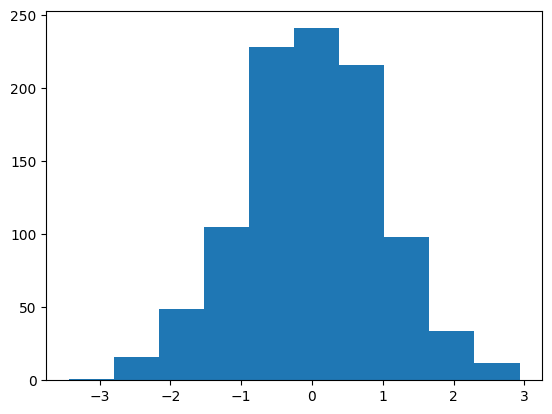

In [32]:
plt.hist(z_group["Height"])

In [33]:
# Veamos una función lambda, que colocará el valor de la media en donde hayan valores faltantes 'na'.
fill_na_mean = lambda x: x.fillna(x.mean())

In [34]:
# No ocurrirá ningún cambio, ya que no hay valores faltantes.
double_group.transform(fill_na_mean)

,Income,Weight,Height
0,19054.268335,64.249207,183.868397
1,19344.700164,87.258622,171.548272
2,18180.016312,57.718215,180.100129
3,21427.311330,81.230200,190.610342
4,16637.346240,78.925128,159.975153
...,...,...,...
995,16684.877794,56.676627,160.134854
996,18108.708490,69.841899,181.157563
997,14300.476192,80.884351,159.855946
998,16601.260632,71.974772,160.385403


## Operaciones diversas muy útiles:

In [35]:
# Mostrar los primeros elementos de cada categoría:
double_group.head(1)

,Gender,Social Class,Income,Weight,Height
0,Male,Rich,19054.268335,64.249207,183.868397
1,Female,Rich,19344.700164,87.258622,171.548272
2,Male,Middle Class,18180.016312,57.718215,180.100129
3,Male,Poor,21427.311330,81.230200,190.610342
4,Female,Poor,16637.346240,78.925128,159.975153
6,Female,Middle Class,19146.155369,65.767689,142.553510


In [36]:
double_group.tail(1)

,Gender,Social Class,Income,Weight,Height
986,Female,Rich,15385.354432,81.847926,154.878576
992,Female,Middle Class,18934.922698,53.168584,138.181020
993,Male,Poor,17837.968142,54.103162,173.151024
994,Male,Rich,20861.889589,68.453544,165.986136
998,Male,Middle Class,16601.260632,71.974772,160.385403
999,Female,Poor,13348.540961,82.140910,163.182006


In [37]:
# Si quiero la información de una fila específica:
double_group.nth(32)

Income     Weight      Height
Gender Social Class                                     
Female Middle Class  17719.919841  62.706817  159.460765
       Poor          14027.221013  74.007495  175.082122
       Rich          21183.659556  63.287027  157.491847
Male   Middle Class  16095.147170  48.085698  166.534863
       Poor          19162.560669  73.300010  153.017588
       Rich          18749.605640  63.308128  162.067316

In [38]:
# Vemos ya en las últimas filas, poca información
double_group.nth(164)

Income     Weight      Height
Gender Social Class                                     
Female Middle Class  16586.322184  86.093558  162.376584
Male   Middle Class  17072.282306  67.909132  178.446308
       Poor          17834.696695  89.137489  164.762840

In [39]:
"""
Se ordena el dataset que inicialmente creamos 'people_sample',
según los criterios "Weight", "Income".
Si aparecieran dos valores weight con el mismo valor numérico,
la diferencia entre sus valores income determinaría sus posiciones.
"""
data_sorted = people_sample.sort_values(["Weight", "Income"])

In [40]:
data_sorted.head(20)

,Gender,Social Class,Income,Weight,Height
166,Female,Rich,17515.713963,28.712216,132.528491
520,Male,Middle Class,24876.712655,30.714804,151.305845
687,Male,Rich,20366.977673,31.477165,156.600348
844,Male,Middle Class,18240.202134,32.332049,154.714697
815,Male,Poor,22332.837045,32.706493,143.510550
192,Female,Rich,18172.065467,33.064205,154.746786
981,Female,Poor,15557.402600,33.757270,174.333447
215,Male,Rich,19903.004946,34.394273,170.486748
916,Male,Rich,21849.776586,35.641790,166.488221
818,Female,Poor,17372.540498,36.538670,167.341086


In [41]:
"""
A continuación, vamos a crear a partir de data_sorted,
una nueva variable de visualización que a su vez se
mostrará dando enfásis al género:
"""
weight_grouped = data_sorted.groupby("Gender")

In [42]:
weight_grouped.head(1)

,Gender,Social Class,Income,Weight,Height
166,Female,Rich,17515.713963,28.712216,132.528491
520,Male,Middle Class,24876.712655,30.714804,151.305845


In [43]:
weight_grouped.tail(1)

,Gender,Social Class,Income,Weight,Height
80,Female,Poor,22263.058509,105.808100,159.280987
150,Male,Middle Class,19403.390890,113.745568,151.868478


# Conjunto de entrenamiento y conjunto de testing.

In [44]:
import pandas as pd
import numpy as np
import sklearn

In [45]:
path1 = "/content/drive/MyDrive/Machine Learning - Python/Datasets - Machine Learning/customer-churn-model/Customer Churn Model.txt"

In [46]:
data1 = pd.read_csv(path1)

In [47]:
data1.head()

,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.


In [48]:
len(data1)

3333

## Dividir utilizando la distribución normal

In [49]:
a = np.random.randn(len(data1))

In [50]:
a

array([-0.22274113,  1.15423148,  0.14871681, ..., -1.1870257 ,
       -1.05709374,  1.01818449])

(array([ 13.,  83., 289., 710., 829., 788., 434., 143.,  38.,   6.]),
 array([-3.20508151, -2.52218257, -1.83928364, -1.1563847 , -0.47348576,
         0.20941317,  0.89231211,  1.57521105,  2.25810998,  2.94100892,
         3.62390785]),
 <BarContainer object of 10 artists>)

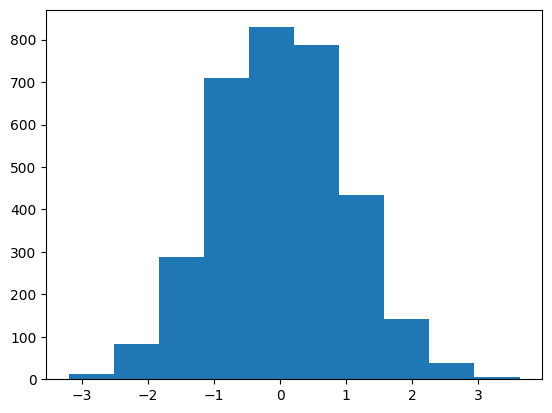

In [51]:
plt.hist(a)

In [52]:
# Revisar los números que son menores a 0.75

check = (a < 0.75)

In [53]:
check

array([ True, False,  True, ...,  True,  True, False])

(array([ 750.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        2583.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

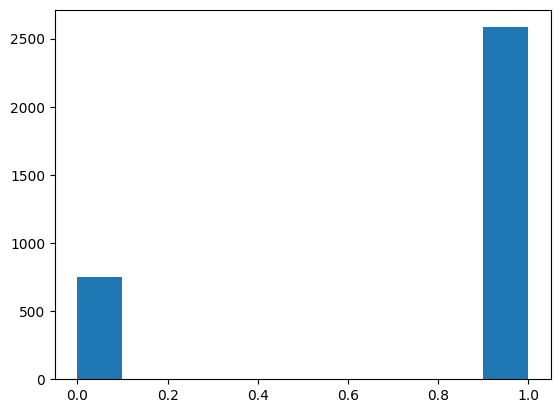

In [54]:
# Ha cambiado en la versión 3.7 de python y necesita hacer un cast de bool a entero

plt.hist(check.astype(int))

In [55]:
training = data1[check]
testing = data1[~check]

In [56]:
training.head()

,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.
5,AL,118,510,391-8027,yes,no,0,223.4,98,37.98,...,101,18.75,203.9,118,9.18,6.3,6,1.70,0,False.
6,MA,121,510,355-9993,no,yes,24,218.2,88,37.09,...,108,29.62,212.6,118,9.57,7.5,7,2.03,3,False.


In [57]:
len(training)

2583

In [58]:
testing.head()

,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
7,MO,147,415,329-9001,yes,no,0,157.0,79,26.69,...,94,8.76,211.8,96,9.53,7.1,6,1.92,0,False.
12,IA,168,408,363-1107,no,no,0,128.8,96,21.90,...,71,8.92,141.1,128,6.35,11.2,2,3.02,1,False.
16,ID,85,408,350-8884,no,yes,27,196.4,139,33.39,...,90,23.88,89.3,75,4.02,13.8,4,3.73,1,False.


In [59]:
len(testing)

750

## Con la libreria `sklearn`

In [60]:
# Ha cambiado en la 3.7 de Python

from sklearn.model_selection import train_test_split

In [61]:
training2, testing2 = train_test_split(data1, test_size = 0.2)

In [62]:
len(training2)

2666

In [63]:
len(testing2)

667

## Usando una función de shuffle

In [64]:
data1.head()

,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.


In [65]:
import sklearn

In [66]:
data1 = sklearn.utils.shuffle(data1)

In [67]:
data1.head()

,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
1525,ID,42,415,363-2193,no,no,0,92.2,108,15.67,...,120,17.95,129.1,73,5.81,13.1,6,3.54,1,False.
1134,TN,105,408,353-8849,no,no,0,206.2,84,35.05,...,138,21.79,117.1,91,5.27,9.0,3,2.43,1,False.
3017,AL,141,408,391-6773,no,no,0,242.8,90,41.28,...,80,19.90,211.5,104,9.52,6.0,3,1.62,5,False.
2310,IL,148,408,395-9270,no,yes,25,230.7,102,39.22,...,109,19.87,215.8,90,9.71,13.5,2,3.65,3,False.
1069,NV,22,510,393-6475,no,no,0,160.4,108,27.27,...,88,18.54,192.9,115,8.68,12.5,4,3.38,1,False.


In [68]:
# El cut_id será el índice que dará con el 75 de las filas
# notar que data1 ha sido modificado por el método .shuffle

cut_id = int(0.75 * len(data1))
train_data = data1[:cut_id]
test_data = data1[cut_id + 1:]

In [69]:
len(train_data)

2499

In [70]:
len(test_data)

833